# Fuel cell + battery hybrid

Hybridizing the hydrogen fuel cell with a battery: the battery supplies a fraction
`phi` of the propulsive power, the fuel cell the rest.

In [1]:
import sys, os
# reuse the baseline configs in examples/common.py (works whether the notebook is run
# from trunk/ or from trunk/notebooks/).
for _p in (os.path.join(os.getcwd(), 'examples'), os.path.join(os.getcwd(), '..', 'examples')):
    if os.path.isdir(_p):
        sys.path.insert(0, _p)
import matplotlib.pyplot as plt
import PhlyGreen as pg
from PhlyGreen import postprocess as pp
from common import fuelcell_battery_config

## Build the design specification

`cruise_phi` is the battery share during cruise (0 reproduces the pure-hydrogen design).

In [2]:
config = fuelcell_battery_config(cruise_phi=0.10)
print('configuration :', config.configuration)

configuration : FuelCellBattery


## Size the aircraft and read the results

In [3]:
aircraft = pg.build_aircraft()
aircraft.configure(config)
r = aircraft.results()
print(f'take-off weight : {r.WTO:8.1f} kg')
print(f'usable H2       : {aircraft.weight.WH2_Fuel:8.1f} kg')
print(f'battery mass    : {r.WBat:8.1f} kg')
print(f'fuel-cell mass  : {r.WPT:8.1f} kg')

take-off weight :  52465.7 kg
usable H2       :    958.9 kg
battery mass    :   4393.5 kg
fuel-cell mass  :  10258.0 kg


## Plot every outcome

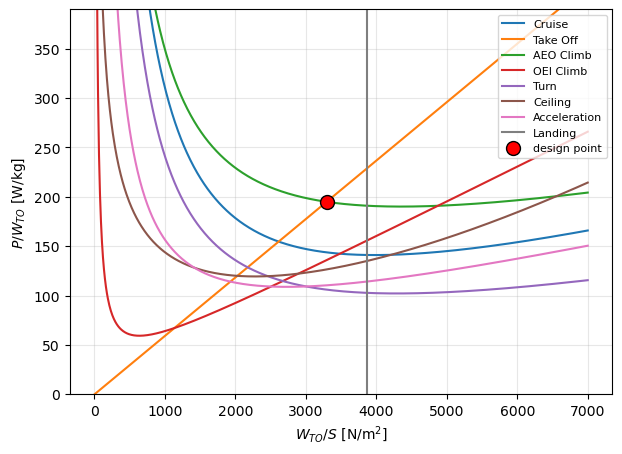

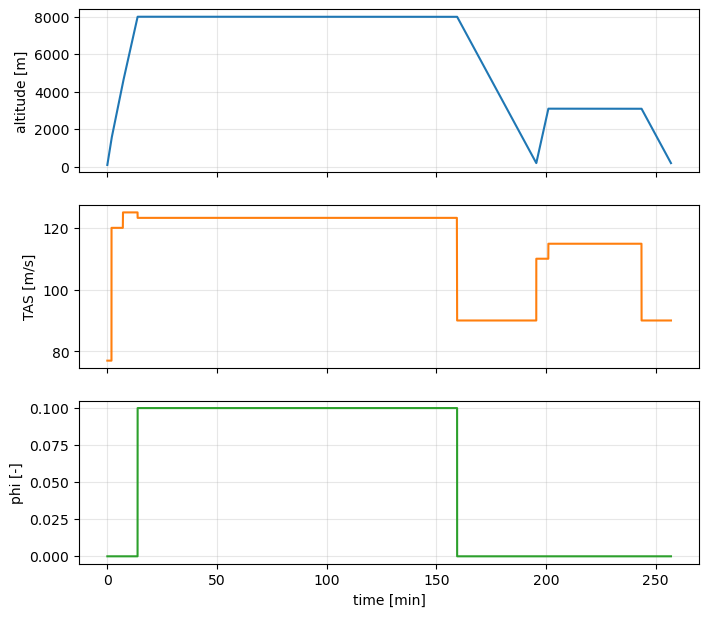

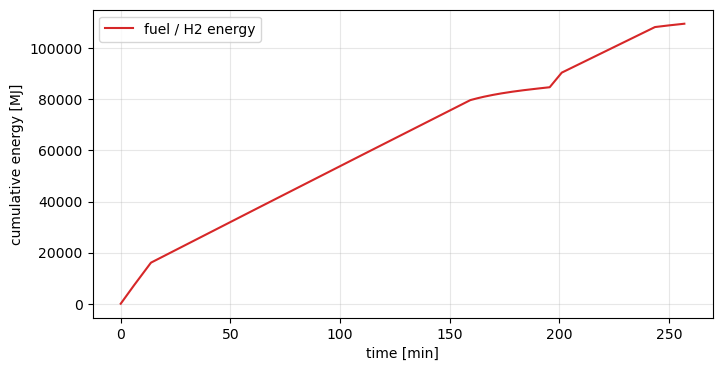

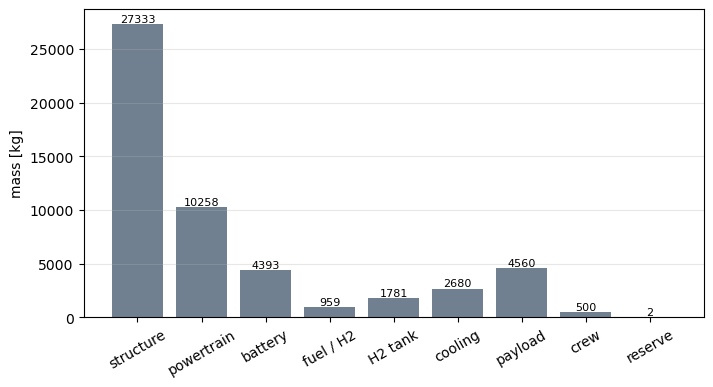

In [4]:
# Every outcome, including the time-resolved ones, via the generic post-processing helpers.
pp.plot_constraint_diagram(aircraft); plt.show()
pp.plot_mission_profile(aircraft);    plt.show()
pp.plot_energy_timeseries(aircraft);  plt.show()
pp.plot_mass_breakdown(aircraft);     plt.show()
